# PROJECT 2

## E-Commerce Fraud Risk Detection using Machine Learning

In [351]:
import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer

plt.style.use("ggplot")

In [352]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [353]:
# Configuration

RANDOM_STATE = 42

TARGET = "is_fraud"

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [354]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df.sample(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1178,ORD201178,2024-09-08,C65107,Monitor,1,70.24,456 Main St,Credit Card,Cancelled,TRK10261578,4,FREESHIP,Google,70.24
865,ORD200865,2023-04-30,C72241,Monitor,4,677.37,156 Main St,Cash,Pending,TRK76270481,8,SAVE10,Google,2709.48
101,ORD200101,2023-11-25,C15283,Printer,1,381.02,152 Main St,Cash,Shipped,TRK19286291,6,NaN,Google,381.02
439,ORD200439,2024-09-08,C91155,Tablet,1,146.32,321 Main St,Online,Shipped,TRK36260319,4,WINTER15,Facebook,146.32
58,ORD200058,2023-01-15,C60190,Phone,4,474.69,202 Main St,Gift Card,Cancelled,TRK70857868,6,SAVE10,Google,1898.76
1120,ORD201120,2025-05-10,C22919,Tablet,1,195.86,267 Main St,Online,Pending,TRK82416295,3,NaN,Facebook,195.86
323,ORD200323,2025-01-26,C29416,Laptop,1,150.17,414 Main St,Debit Card,Returned,TRK63820842,1,SAVE10,Referral,150.17
974,ORD200974,2023-09-27,C30722,Desk,5,266.78,274 Main St,Gift Card,Cancelled,TRK52088168,5,NaN,Email,1333.90
411,ORD200411,2024-06-19,C66567,Desk,2,39.51,981 Main St,Online,Shipped,TRK21174822,5,NaN,Facebook,79.02
855,ORD200855,2023-05-25,C41331,Monitor,5,240.61,785 Main St,Credit Card,Shipped,TRK94198179,10,FREESHIP,Email,1203.05


In [355]:
print("Shape :\n", df.shape)
print("\n")
print("Columns :\n",df.columns.tolist())
print("\n")
print("Data Types :\n",df.dtypes)
print("\n")
print("Memory Usage :\n",df.memory_usage(deep=True))
print("\n")
df.info()
print("\n")
df.describe(include="all").T

Shape :
 (1200, 14)


Columns :
 ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


Data Types :
 OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object


Memory Usage :
 Index                132
OrderID            69600
Date               70800
CustomerID         66000
Product            65670
Quantity            9600
UnitPrice           9600
ShippingAddress    72000
PaymentMethod      68296
OrderStatus        68409
TrackingNumber     72000
ItemsInCart         9600
CouponCode         60103
ReferralSource  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderID,1200,1200,ORD201183,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,1200,671,2023-08-20,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1200,1189,C38840,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,1200,7,Printer,181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1200.0,NaN,NaN,NaN,2.945833,1.407557,1.0,2.0,3.0,4.0,5.0
UnitPrice,1200.0,NaN,NaN,NaN,356.41275,197.177146,11.39,186.0625,364.21,521.57,699.93
ShippingAddress,1200,655,533 Main St,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,1200,5,Online,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OrderStatus,1200,5,Cancelled,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackingNumber,1200,1200,TRK83653396,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Values

In [356]:
missing = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":round(df.isnull().mean()*100,2)
})

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage
CouponCode,309,25.75
OrderID,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
Date,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
OrderStatus,0,0.00
PaymentMethod,0,0.00


### Duplicate Records

In [357]:
duplicates=df.duplicated().sum()

print("Duplicate Records :",duplicates)

Duplicate Records : 0


### Unique Values

In [358]:
unique=pd.DataFrame(df.nunique())

unique.columns=["Unique Values"]

unique.sort_values("Unique Values")

,Unique Values
CouponCode,3
PaymentMethod,5
OrderStatus,5
Quantity,5
ReferralSource,5
Product,7
ItemsInCart,10
ShippingAddress,655
Date,671
CustomerID,1189


### Convert Date

In [359]:
df["Date"]=pd.to_datetime(df["Date"])

print(df["Date"].head())

0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[ns]


In [360]:
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Day"]=df["Date"].dt.day
df["Weekday"]=df["Date"].dt.day_name()
df["Quarter"]=df["Date"].dt.quarter
df["WeekOfYear"]=df["Date"].dt.isocalendar().week

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday,Quarter,WeekOfYear
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,Wednesday,1,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,Friday,3,34
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,Tuesday,1,9
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,Sunday,4,41
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,Thursday,2,19


### Numerical Columns

In [361]:
num_cols=df.select_dtypes(include=np.number).columns

num_cols

Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'Year', 'Month',
       'Day', 'Quarter', 'WeekOfYear'],
      dtype='object')

### Categorical Columns

In [362]:
cat_cols=df.select_dtypes(include="object").columns

cat_cols

Index(['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod',
       'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource',
       'Weekday'],
      dtype='object')

### Correlation Heatmap

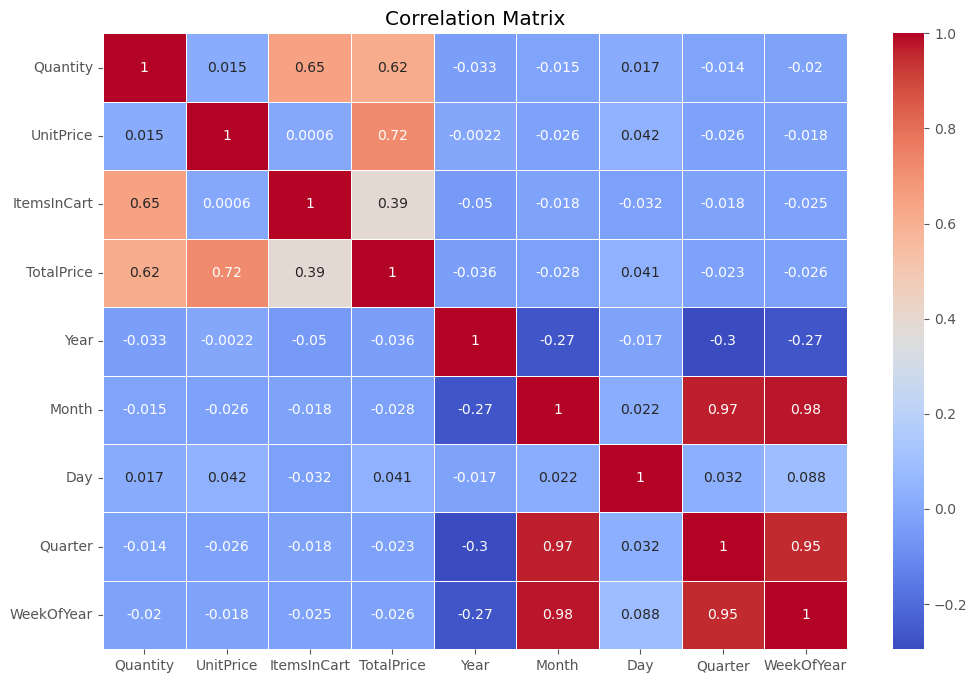

In [363]:
plt.figure(figsize=(12,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm",
            linewidth=0.5)

plt.title("Correlation Matrix")

plt.show()

### Distribution Plots


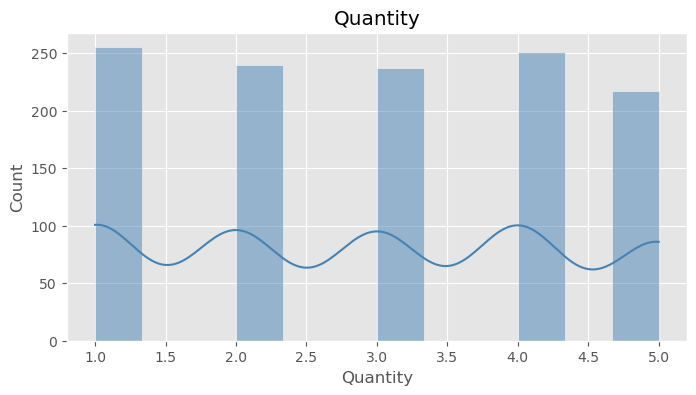

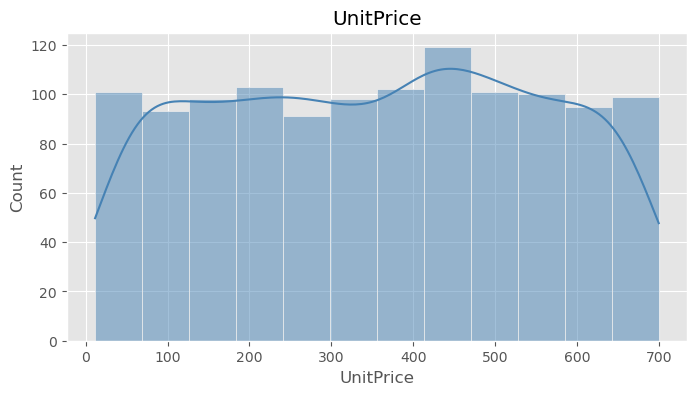

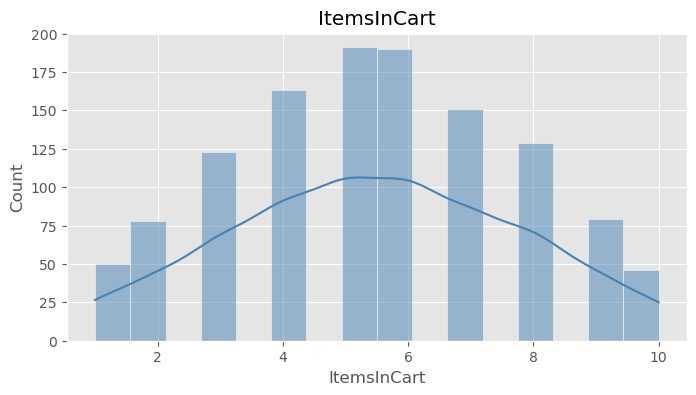

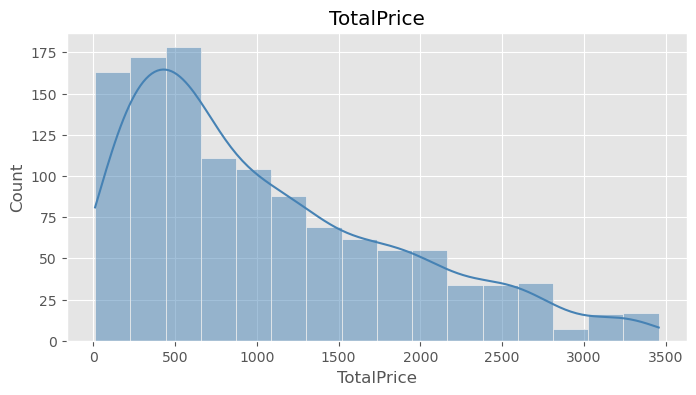

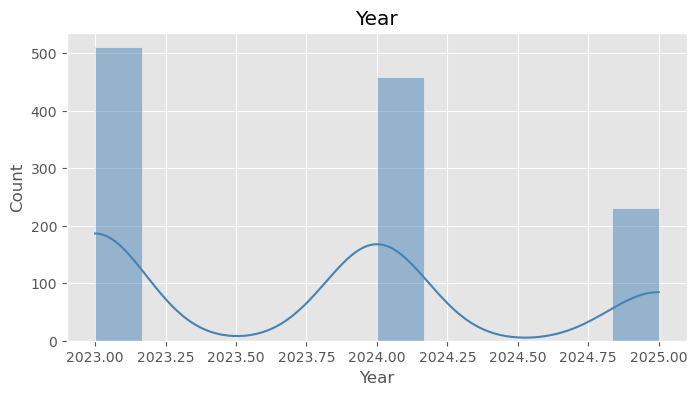

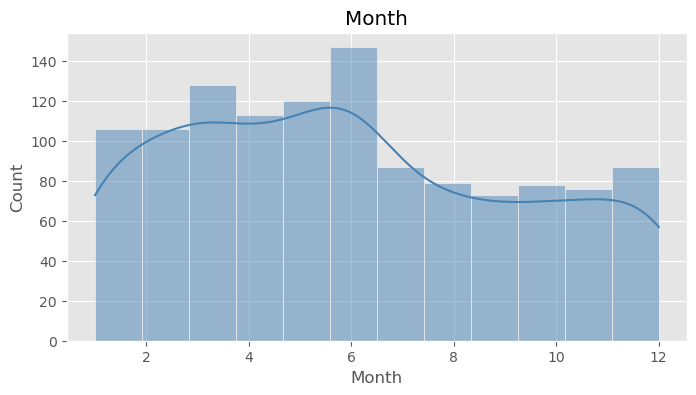

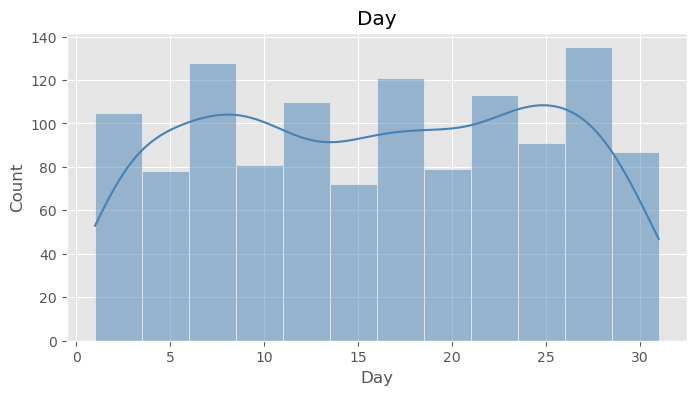

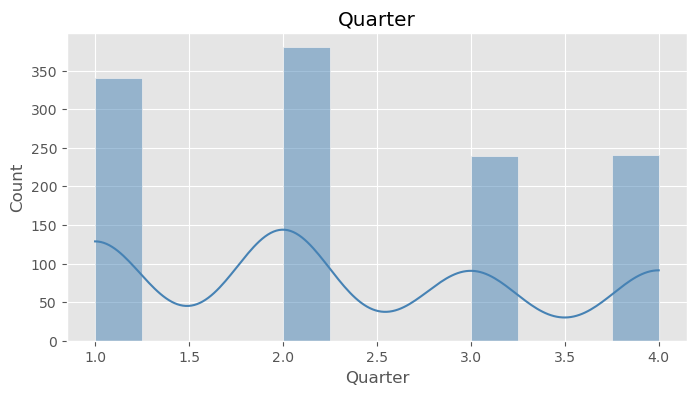

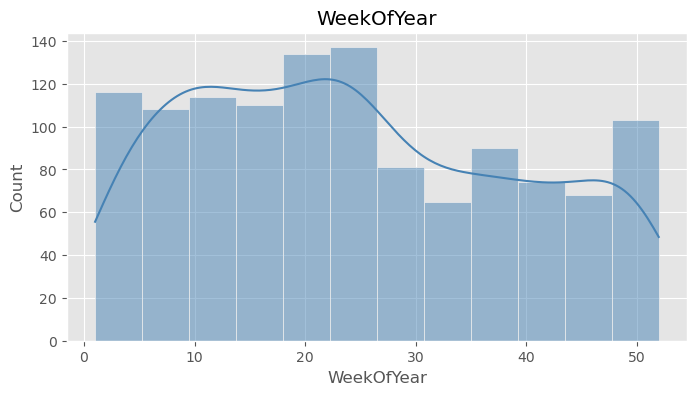

In [364]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(df[col],
                 kde=True,
                 color="steelblue")
    
    plt.title(col)
    
    plt.show()

### Boxplots

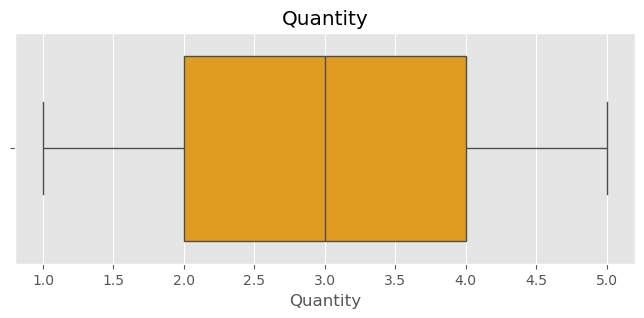

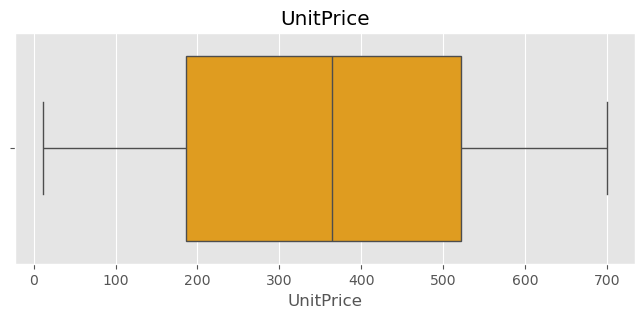

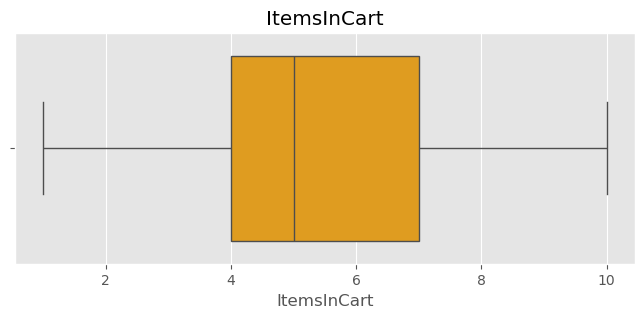

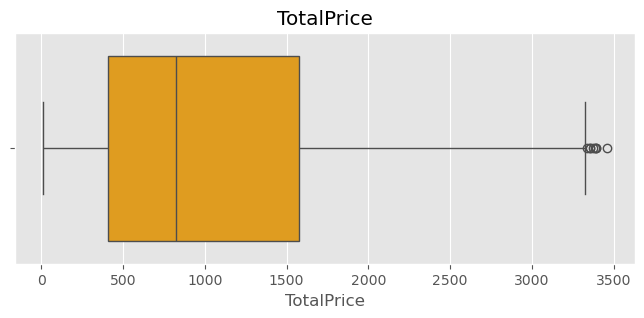

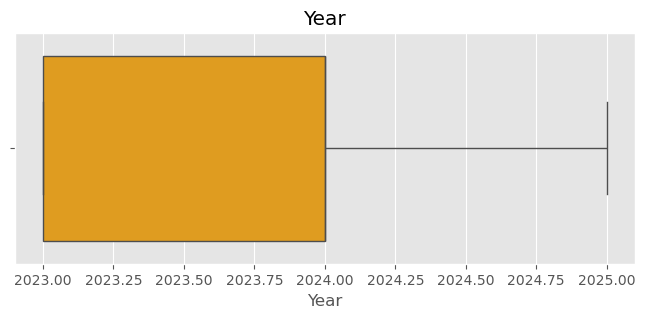

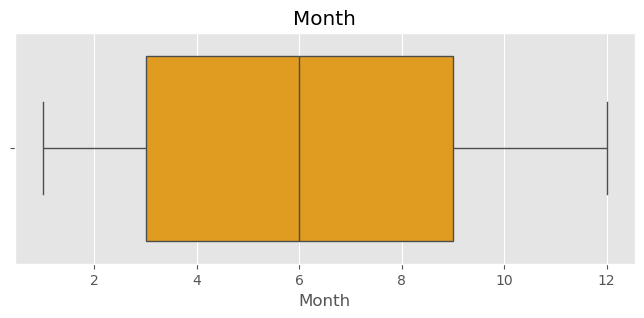

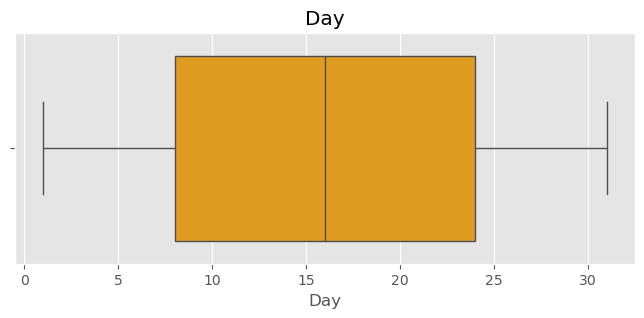

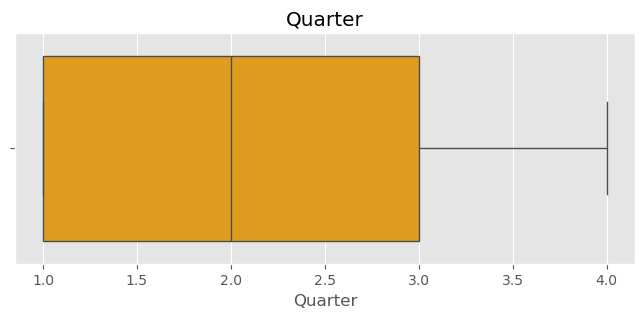

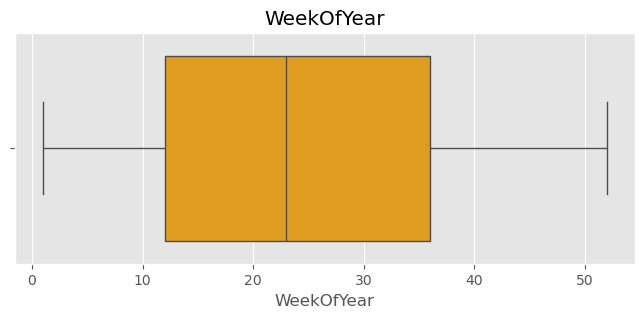

In [365]:
for col in num_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df[col],
                color="orange")
    
    plt.title(col)
    
    plt.show()

### Countplots

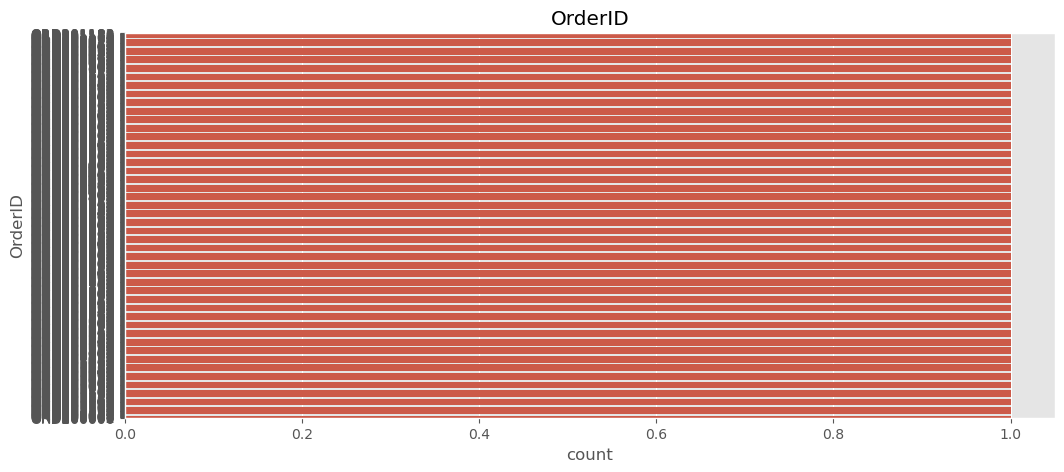

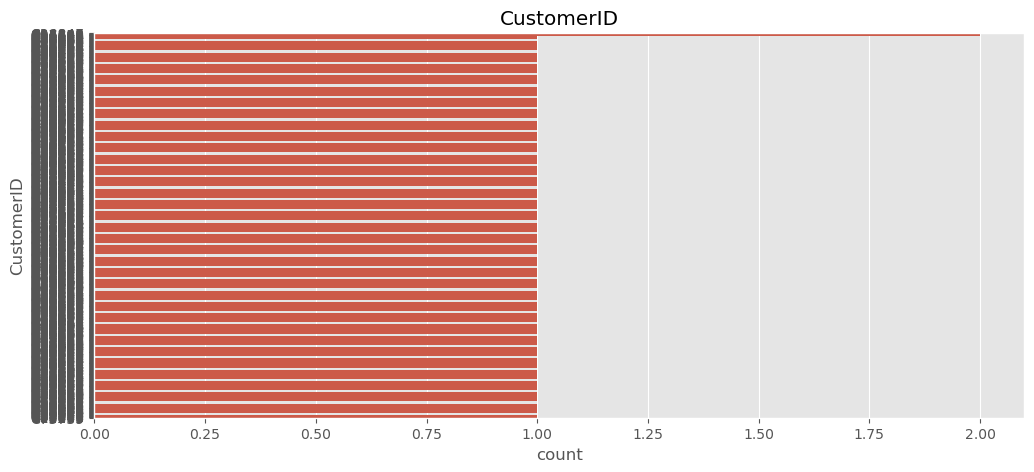

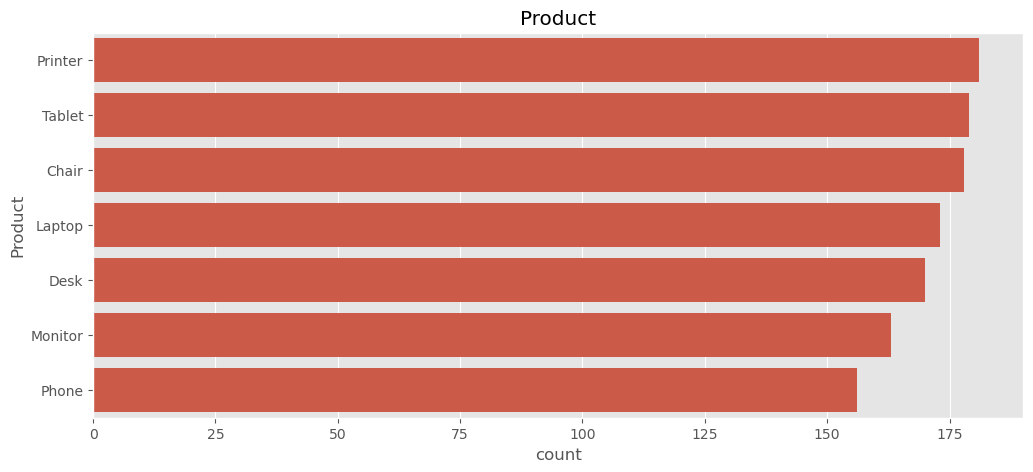

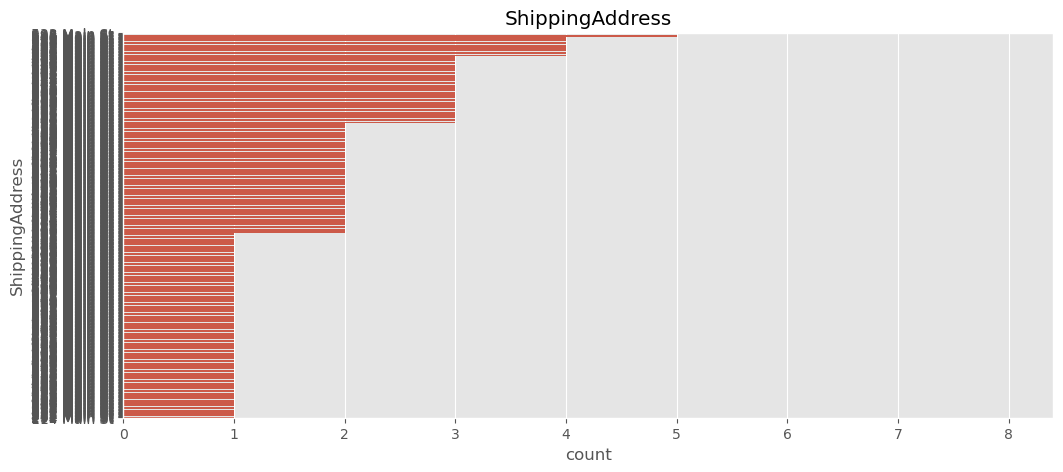

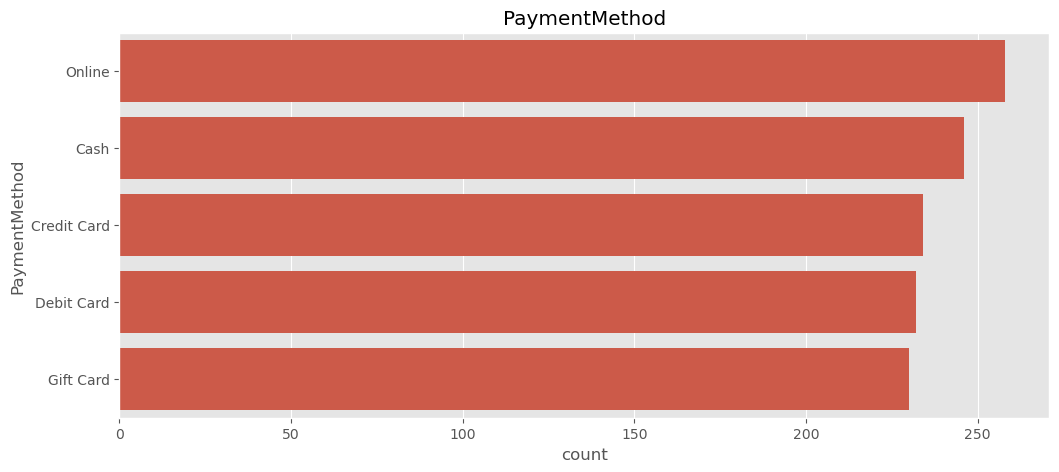

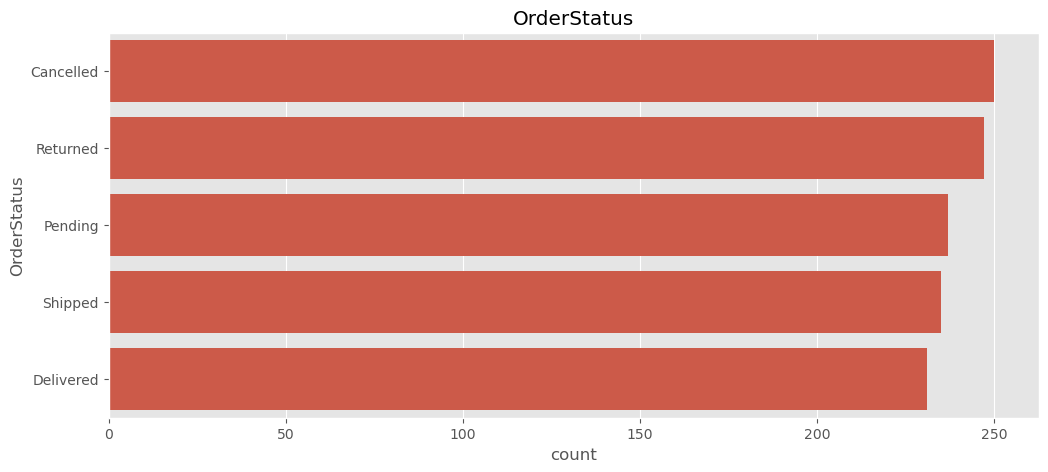

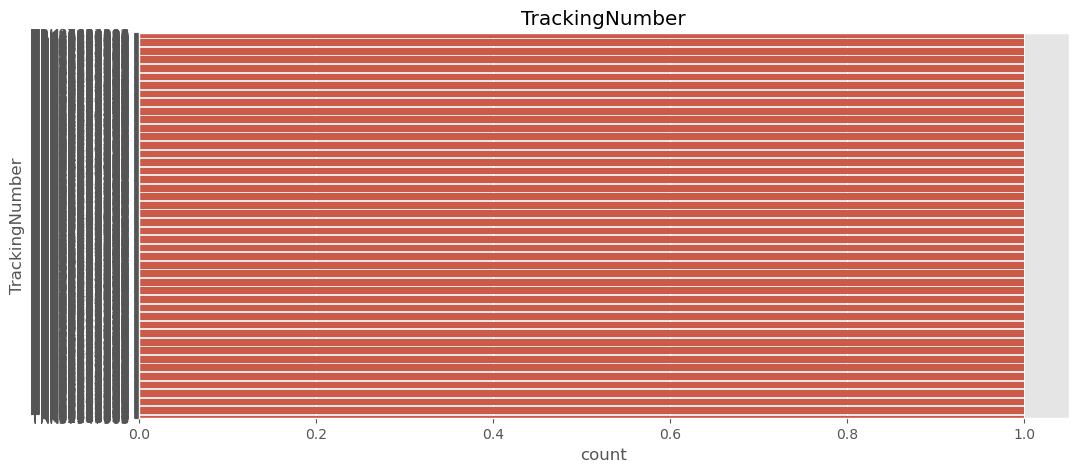

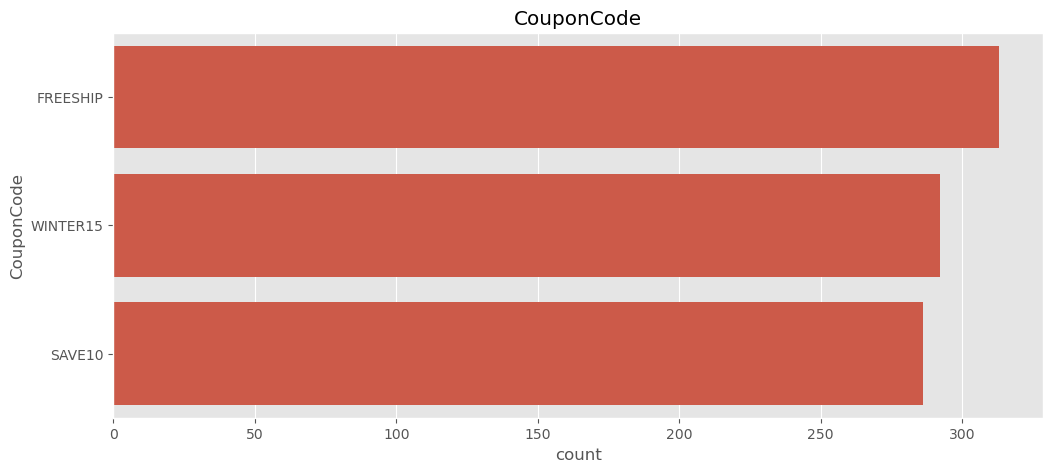

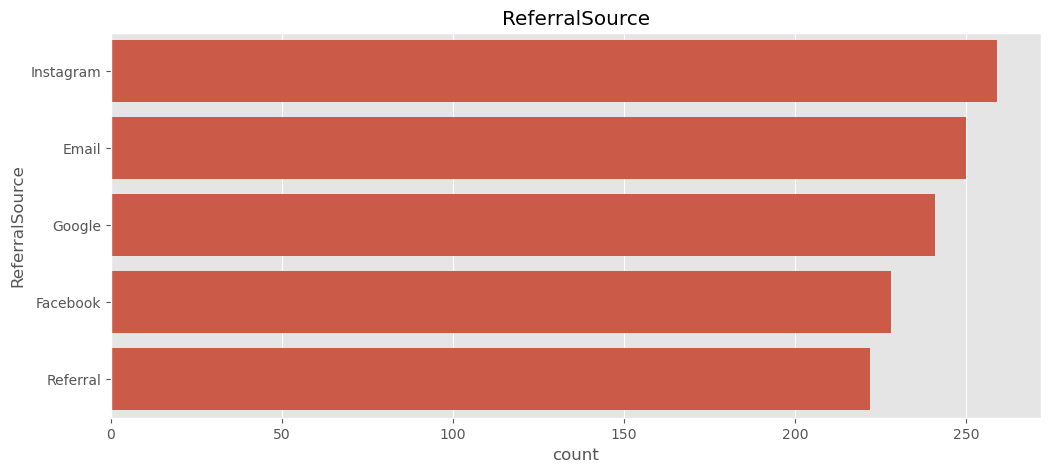

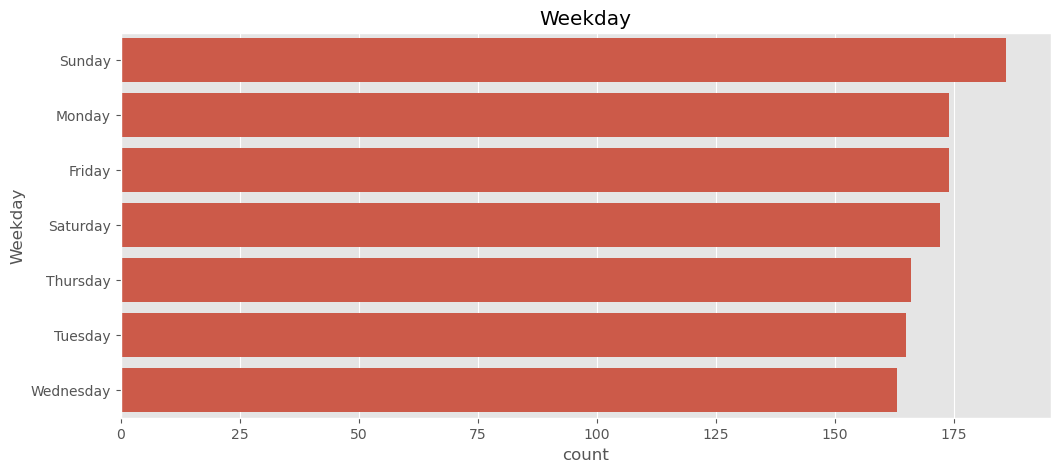

In [366]:
for col in cat_cols:
    
    plt.figure(figsize=(12,5))
    
    sns.countplot(y=df[col],
                  order=df[col].value_counts().index)
    
    plt.title(col)
    
    plt.show()

### Top Products

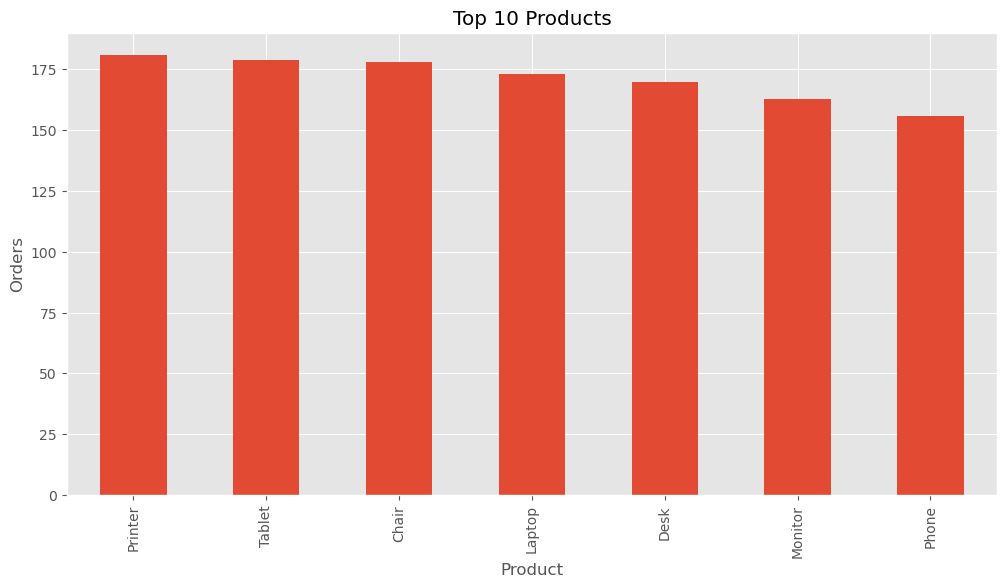

In [367]:
plt.figure(figsize=(12,6))

df["Product"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Products")

plt.ylabel("Orders")

plt.show()

### Payment Method Analysis

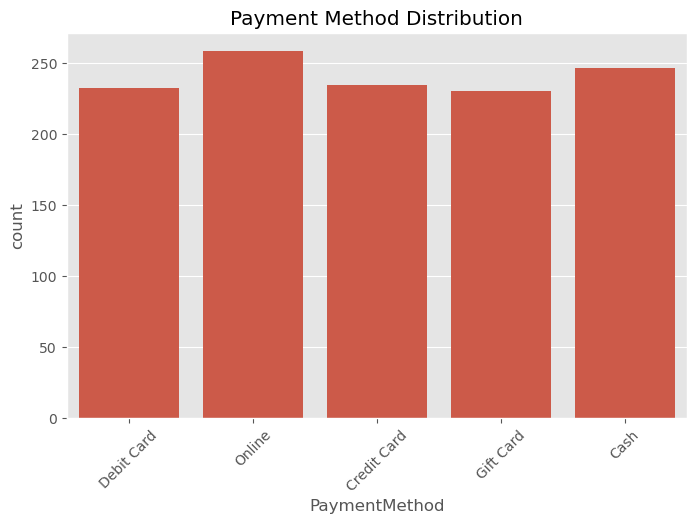

In [368]:
plt.figure(figsize=(8,5))

sns.countplot(x="PaymentMethod",
              data=df)

plt.xticks(rotation=45)

plt.title("Payment Method Distribution")

plt.show()

### Monthly Sales Trend

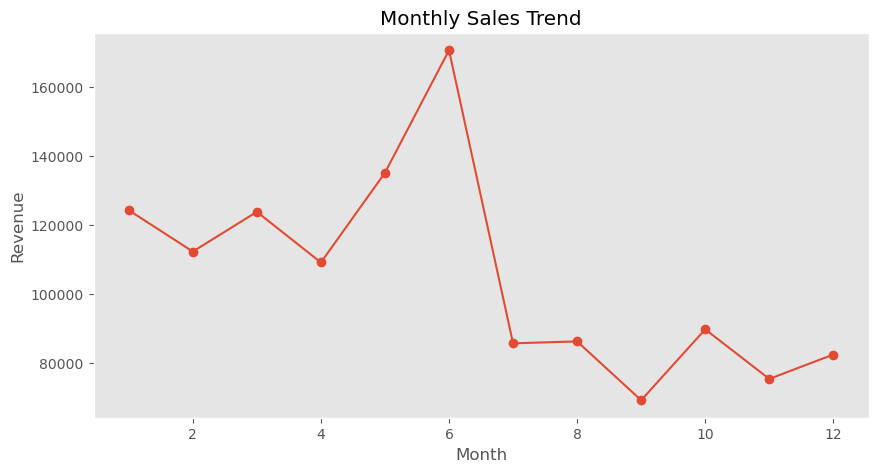

In [369]:
monthly=df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.ylabel("Revenue")

plt.grid()

plt.show()

### Missing Value Treatment

In [370]:
print("Missing Values Before Treatment")

print(df.isnull().sum())

Missing Values Before Treatment
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
Year                 0
Month                0
Day                  0
Weekday              0
Quarter              0
WeekOfYear           0
dtype: int64


In [371]:
# Numerical Columns

num_cols=df.select_dtypes(include=np.number).columns

# Categorical Columns

cat_cols=df.select_dtypes(include="object").columns

# Fill Numerical Columns

for col in num_cols:

    if df[col].isnull().sum()>0:

        df[col].fillna(df[col].median(),inplace=True)

# Fill Categorical Columns

for col in cat_cols:

    if df[col].isnull().sum()>0:

        df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\saksh\AppData\Local\Temp\ipykernel_9260\1530003262.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [372]:
print("Missing Values After Treatment")

print(df.isnull().sum())

Missing Values After Treatment
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Year               0
Month              0
Day                0
Weekday            0
Quarter            0
WeekOfYear         0
dtype: int64


### Outlier Detection using IQR

In [373]:
def detect_outliers_iqr(data,column):

    Q1=data[column].quantile(0.25)

    Q3=data[column].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    return data[(data[column]<lower)|(data[column]>upper)]

In [374]:
for col in ["Quantity","UnitPrice","ItemsInCart","TotalPrice"]:

    outliers=detect_outliers_iqr(df,col)

    print(col,"=",len(outliers))

Quantity = 0
UnitPrice = 0
ItemsInCart = 0
TotalPrice = 8


In [375]:
from scipy.stats import zscore

z_cols = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

z = np.abs(zscore(df[z_cols]))

z_df = pd.DataFrame(z, columns=z_cols)

z_df.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
0,1.459993,1.086822,0.664173,2.195362
1,0.672248,1.040426,1.089419,0.916723
2,1.459993,0.985653,1.102571,2.073705
3,1.382995,0.422247,0.212623,0.952732
4,0.749246,1.367855,1.102571,1.769427


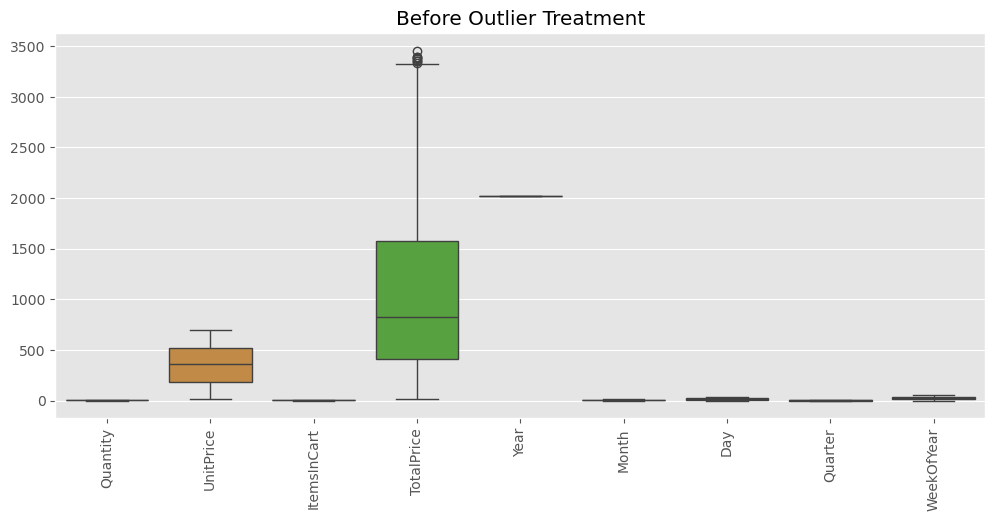

In [376]:
plt.figure(figsize=(12,5))

sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)

plt.title("Before Outlier Treatment")

plt.show()

In [377]:
# Fraud Risk Score

risk_score=np.zeros(len(df))

In [378]:
# High Total Price

risk_score += np.where(

    df["TotalPrice"] >

    df["TotalPrice"].quantile(0.95),

    35,

    0

)

In [379]:
# Large Cart

risk_score += np.where(

    df["ItemsInCart"] >

    df["ItemsInCart"].quantile(0.90),

    20,

    0

)

In [380]:
# High Quantity

risk_score += np.where(

    df["Quantity"] >

    df["Quantity"].quantile(0.90),

    15,

    0

)

In [381]:
# Coupon Used

risk_score += np.where(

    df["CouponCode"].notnull(),

    10,

    0

)

In [382]:
# Online Payment

risk_score += np.where(

    df["PaymentMethod"].isin(

        ["Credit Card","Debit Card","UPI"]

    ),

    10,

    0

)

In [383]:
# Duplicate Shipping Address

duplicate_address=df.groupby(

    "ShippingAddress"

)["OrderID"].transform("count")

risk_score += np.where(

    duplicate_address>3,

    10,

    0

)

In [384]:
# Customer Daily Orders

daily_orders=df.groupby(

    ["CustomerID","Date"]

)["OrderID"].transform("count")

risk_score += np.where(

    daily_orders>2,

    15,

    0

)

In [385]:
df["FraudRiskScore"]=risk_score

df["FraudRiskScore"].describe()

count    1200.000000
mean       17.800000
std        10.484191
min        10.000000
25%        10.000000
50%        20.000000
75%        20.000000
max        75.000000
Name: FraudRiskScore, dtype: float64

### Create Target

In [386]:
df["is_fraud"]=np.where(

    df["FraudRiskScore"]>=50,

    1,

    0

)

df["is_fraud"].value_counts()

is_fraud
0    1170
1      30
Name: count, dtype: int64

### Fraud Distribution

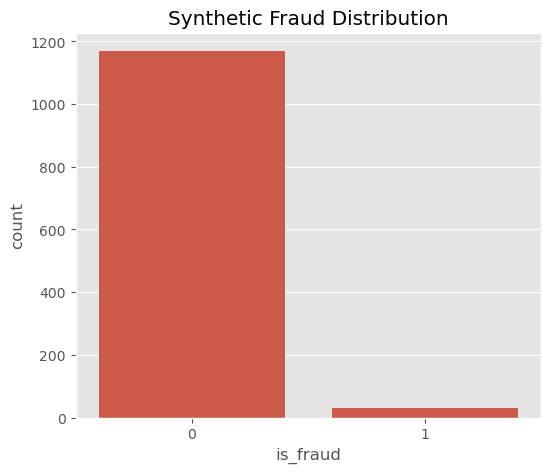

In [387]:
plt.figure(figsize=(6,5))

sns.countplot(

    x=df["is_fraud"]

)

plt.title("Synthetic Fraud Distribution")

plt.show()

In [388]:
fraud=df["is_fraud"].value_counts(normalize=True)*100

print(fraud)

is_fraud
0    97.5
1     2.5
Name: proportion, dtype: float64


### Feature Engineering

In [389]:
# Average Product Price

df["AveragePrice"]=df["TotalPrice"]/df["Quantity"]

In [390]:
# High Value Transaction

df["HighValueTransaction"]=np.where(

    df["TotalPrice"]>

    df["TotalPrice"].median(),

    1,

    0

)

In [391]:
# Weekend Flag

df["WeekendFlag"]=np.where(

    df["Weekday"].isin(

        ["Saturday","Sunday"]

    ),

    1,

    0

)

In [392]:
# Customer Purchase Count

df["CustomerPurchaseCount"]=df.groupby(

    "CustomerID"

)["OrderID"].transform("count")

In [393]:
# Customer Total Spending

df["CustomerSpending"]=df.groupby(

    "CustomerID"

)["TotalPrice"].transform("sum")

In [394]:
# Product Popularity

df["ProductPopularity"]=df.groupby(

    "Product"

)["OrderID"].transform("count")

In [395]:
# Average Order Value

df["AverageOrderValue"]=df.groupby(

    "CustomerID"

)["TotalPrice"].transform("mean")

In [396]:
# Customer Risk Category

conditions=[

    df["FraudRiskScore"]<30,

    df["FraudRiskScore"]<60,

    df["FraudRiskScore"]>=60

]

choices=[

    "Low",

    "Medium",

    "High"

]

df["CustomerRiskCategory"]=np.select(

    conditions,

    choices,

    default="Low"

)

In [397]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday,Quarter,WeekOfYear,FraudRiskScore,is_fraud,AveragePrice,HighValueTransaction,WeekendFlag,CustomerPurchaseCount,CustomerSpending,ProductPopularity,AverageOrderValue,CustomerRiskCategory
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,1,4,Wednesday,1,1,55.0,1,570.62,1,0,1,2853.10,163,2853.10,Medium
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,23,Friday,3,34,10.0,0,151.35,0,0,1,302.70,156,302.70,Low
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,2,27,Tuesday,1,9,55.0,1,550.68,1,0,1,2753.40,179,2753.40,Medium
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,15,Sunday,4,41,20.0,0,273.19,0,1,1,273.19,178,273.19,Low
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,5,8,Thursday,2,19,10.0,0,626.01,1,0,1,2504.04,181,2504.04,Low


### Encoding

In [398]:
encoder=LabelEncoder()

for col in df.select_dtypes(include="object").columns:

    df[col]=encoder.fit_transform(df[col].astype(str))

### Scaling

In [399]:
scaler=StandardScaler()

scaled_columns=[

    "Quantity",

    "UnitPrice",

    "ItemsInCart",

    "TotalPrice",

    "FraudRiskScore",

    "AveragePrice",

    "CustomerSpending"

]

df[scaled_columns]=scaler.fit_transform(

    df[scaled_columns]

)

### Power Transformation

In [400]:
pt=PowerTransformer()

df[scaled_columns]=pt.fit_transform(

    df[scaled_columns]

)

In [401]:
print(df.shape)
df.head()

(1200, 30)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday,Quarter,WeekOfYear,FraudRiskScore,is_fraud,AveragePrice,HighValueTransaction,WeekendFlag,CustomerPurchaseCount,CustomerSpending,ProductPopularity,AverageOrderValue,CustomerRiskCategory
0,0,2023-01-04,856,3,1.451372,1.089494,596,2,4,359,0.664537,1,3,1.727213,2023,1,4,6,1,1,2.109004,1,1.089494,1,0,1,1.700160,163,2853.10,2
1,1,2024-08-23,888,4,-0.668188,-1.039167,512,4,4,1074,-1.089609,1,4,-1.045815,2024,8,23,0,3,34,-0.991154,0,-1.039167,0,0,1,-1.059527,156,302.70,1
2,2,2024-02-27,950,6,1.451372,0.986131,294,1,0,416,1.102362,0,0,1.671932,2024,2,27,5,1,9,2.109004,1,0.986131,1,0,1,1.645666,179,2753.40,2
3,3,2023-10-15,332,0,-1.390552,-0.430938,124,2,3,691,-0.211923,1,1,-1.110376,2023,10,15,3,4,41,0.648312,0,-0.430938,0,1,1,-1.123814,178,273.19,1
4,4,2025-05-08,951,5,0.752528,1.377390,407,4,1,245,1.102362,1,0,1.525983,2025,5,8,4,2,19,-0.991154,0,1.377390,1,0,1,1.501641,181,2504.04,1


### Separate Features & Target

In [402]:
X = df.drop(columns=[
    "is_fraud",
    "FraudRiskScore",
    "CustomerRiskCategory"
], errors="ignore")

y = df["is_fraud"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nFeatures Used:")
print(X.columns.tolist())

Feature Shape : (1200, 27)
Target Shape : (1200,)

Features Used:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year', 'Month', 'Day', 'Weekday', 'Quarter', 'WeekOfYear', 'AveragePrice', 'HighValueTransaction', 'WeekendFlag', 'CustomerPurchaseCount', 'CustomerSpending', 'ProductPopularity', 'AverageOrderValue']


### Correlation with Target

In [403]:
corr = df.corr(numeric_only=True)

target_corr = corr["is_fraud"].sort_values(ascending=False)

target_corr

is_fraud                 1.000000
AverageOrderValue        0.388846
FraudRiskScore           0.349619
TotalPrice               0.291758
CustomerSpending         0.287186
UnitPrice                0.224597
AveragePrice             0.224597
Quantity                 0.213755
ItemsInCart              0.181147
HighValueTransaction     0.160128
CustomerRiskCategory     0.130565
Product                  0.054686
Day                      0.054191
WeekOfYear               0.017405
Quarter                  0.017039
CouponCode               0.014500
Month                    0.013013
Weekday                  0.003833
ReferralSource           0.002372
TrackingNumber           0.001325
OrderStatus             -0.009965
ProductPopularity       -0.014371
Year                    -0.014399
CustomerPurchaseCount   -0.021883
OrderID                 -0.022974
ShippingAddress         -0.026876
CustomerID              -0.053752
PaymentMethod           -0.053840
WeekendFlag             -0.057748
Name: is_fraud

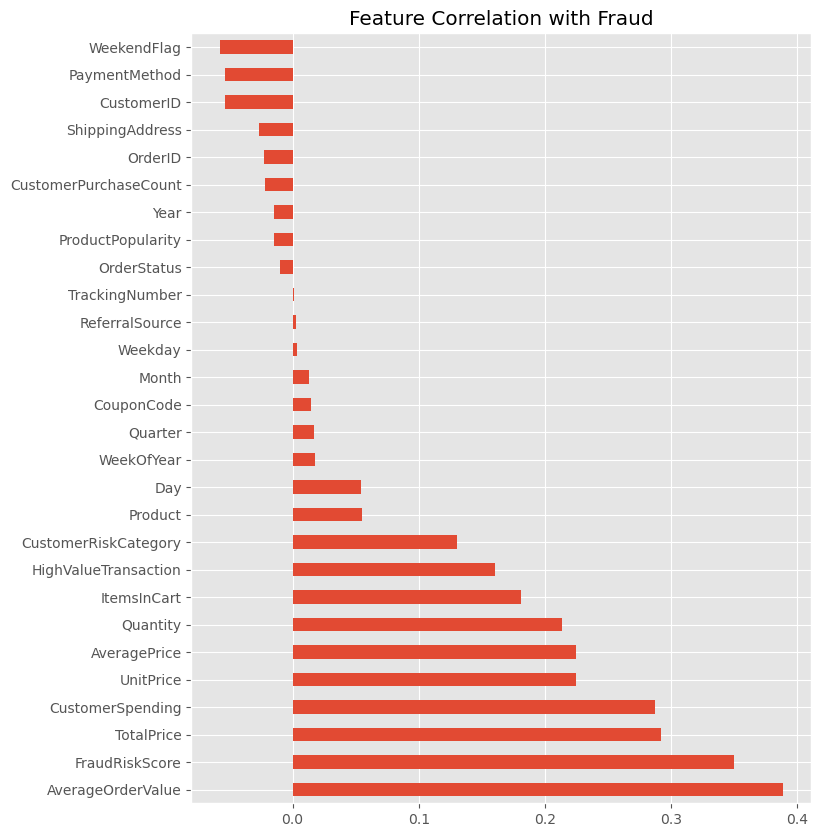

In [404]:
plt.figure(figsize=(8,10))

target_corr.drop("is_fraud").plot(kind="barh")

plt.title("Feature Correlation with Fraud")

plt.show()

### Variance Threshold

In [405]:
print(X.dtypes)

OrderID                           int64
Date                     datetime64[ns]
CustomerID                        int64
Product                           int64
Quantity                        float64
UnitPrice                       float64
ShippingAddress                   int64
PaymentMethod                     int64
OrderStatus                       int64
TrackingNumber                    int64
ItemsInCart                     float64
CouponCode                        int64
ReferralSource                    int64
TotalPrice                      float64
Year                              int32
Month                             int32
Day                               int32
Weekday                           int64
Quarter                           int32
WeekOfYear                       UInt32
AveragePrice                    float64
HighValueTransaction              int64
WeekendFlag                       int64
CustomerPurchaseCount             int64
CustomerSpending                float64


In [406]:
X = X.drop(columns=["Date"], errors="ignore")

In [407]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

selector.fit(X)

selected_columns = X.columns[selector.get_support()]

print(selected_columns)

Index(['OrderID', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year',
       'Month', 'Day', 'Weekday', 'Quarter', 'WeekOfYear', 'AveragePrice',
       'HighValueTransaction', 'WeekendFlag', 'CustomerPurchaseCount',
       'CustomerSpending', 'ProductPopularity', 'AverageOrderValue'],
      dtype='object')


In [408]:
X = X[selected_columns]

print(X.shape)

(1200, 26)


### Mutual Information

In [409]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X_numeric = X.select_dtypes(include=["number"])

# Calculate Mutual Information
mi_scores = mutual_info_classif(
    X_numeric,
    y,
    random_state=42
)

mi = pd.DataFrame({
    "Feature": X_numeric.columns,
    "MI Score": mi_scores
})

mi = mi.sort_values(by="MI Score", ascending=False)

print(mi)

                  Feature  MI Score
12             TotalPrice  0.082150
25      AverageOrderValue  0.078999
23       CustomerSpending  0.078247
19           AveragePrice  0.038331
4               UnitPrice  0.038331
3                Quantity  0.032075
9             ItemsInCart  0.020633
20   HighValueTransaction  0.013930
13                   Year  0.007771
11         ReferralSource  0.006118
24      ProductPopularity  0.005829
8          TrackingNumber  0.004987
21            WeekendFlag  0.002927
6           PaymentMethod  0.002316
16                Weekday  0.002088
7             OrderStatus  0.001991
1              CustomerID  0.001204
2                 Product  0.001187
18             WeekOfYear  0.000684
0                 OrderID  0.000219
5         ShippingAddress  0.000000
10             CouponCode  0.000000
17                Quarter  0.000000
15                    Day  0.000000
14                  Month  0.000000
22  CustomerPurchaseCount  0.000000


C:\Users\saksh\AppData\Local\Temp\ipykernel_9260\2117166325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


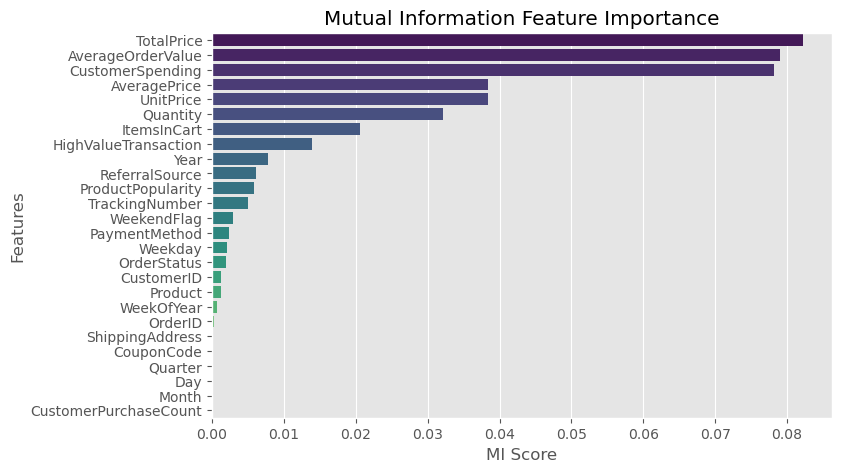

In [410]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=mi,
    x="MI Score",
    y="Feature",
    palette="viridis"
)

plt.title("Mutual Information Feature Importance")
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.show()

### Random Forest Importance

In [411]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use only numeric features
X_rf = X.select_dtypes(include=["number"])

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rf, y)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X_rf.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
12             TotalPrice    0.209645
23       CustomerSpending    0.141537
25      AverageOrderValue    0.140661
6           PaymentMethod    0.059634
4               UnitPrice    0.052106
9             ItemsInCart    0.050714
19           AveragePrice    0.049660
0                 OrderID    0.030820
18             WeekOfYear    0.029406
1              CustomerID    0.029262
3                Quantity    0.026550
8          TrackingNumber    0.024461
14                  Month    0.022092
5         ShippingAddress    0.021377
15                    Day    0.020183
2                 Product    0.016647
11         ReferralSource    0.012180
16                Weekday    0.011867
17                Quarter    0.011085
24      ProductPopularity    0.010124
13                   Year    0.008286
21            WeekendFlag    0.007562
7             OrderStatus    0.006634
10             CouponCode    0.004945
20   HighValueTransaction    0.001564
22  Customer

C:\Users\saksh\AppData\Local\Temp\ipykernel_9260\3870302271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


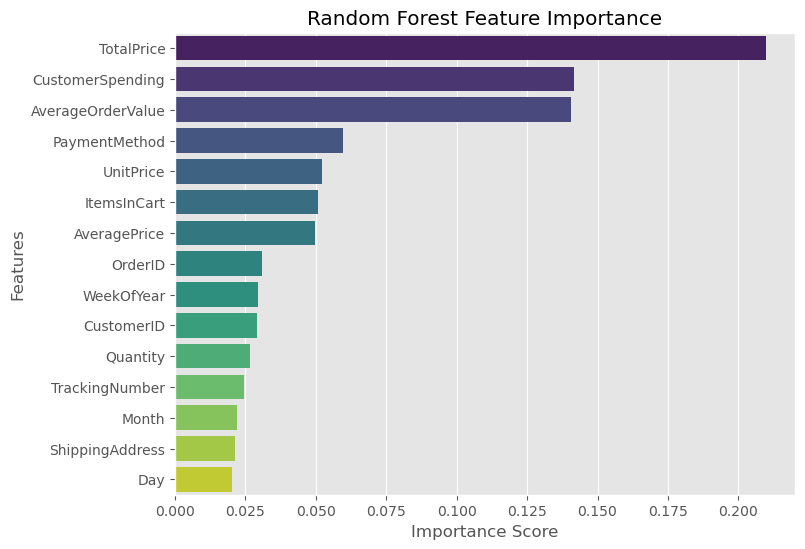

In [412]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [413]:
top_features = importance.head(10)["Feature"].tolist()

print("Top 10 Features:")
print(top_features)

Top 10 Features:
['TotalPrice', 'CustomerSpending', 'AverageOrderValue', 'PaymentMethod', 'UnitPrice', 'ItemsInCart', 'AveragePrice', 'OrderID', 'WeekOfYear', 'CustomerID']


In [414]:
 #X = X[top_features]

In [415]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(

    rf,

    X,

    y,

    random_state=42,

    scoring="f1"

)

perm_importance = pd.Series(

    perm.importances_mean,

    index=X.columns

)

perm_importance.sort_values(

    ascending=False

).head(20)

TotalPrice           0.190588
ItemsInCart          0.034606
AverageOrderValue    0.016949
PaymentMethod        0.013676
CustomerID           0.000000
OrderID              0.000000
ShippingAddress      0.000000
UnitPrice            0.000000
Product              0.000000
Quantity             0.000000
TrackingNumber       0.000000
OrderStatus          0.000000
ReferralSource       0.000000
CouponCode           0.000000
Month                0.000000
Day                  0.000000
Weekday              0.000000
Year                 0.000000
Quarter              0.000000
WeekOfYear           0.000000
dtype: float64

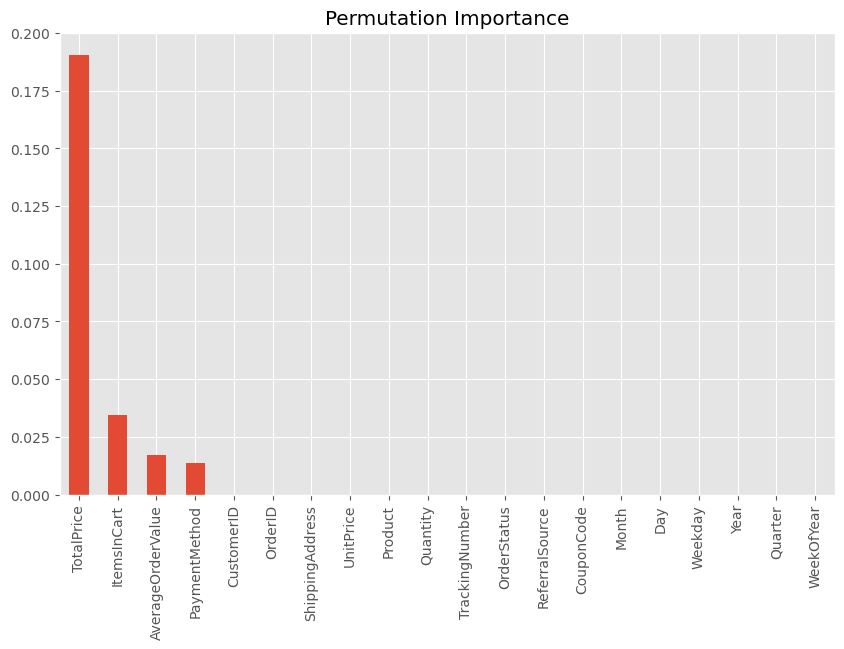

In [416]:
plt.figure(figsize=(10,6))

perm_importance.sort_values(

    ascending=False

).head(20).plot(

    kind="bar"

)

plt.title("Permutation Importance")

plt.show()

### Recursive Feature Elimination

In [417]:
from sklearn.feature_selection import RFE

rfe = RFE(

    estimator=RandomForestClassifier(),

    n_features_to_select=10

)

rfe.fit(X,y)

selected = X.columns[rfe.support_]

selected

Index(['OrderID', 'CustomerID', 'UnitPrice', 'PaymentMethod', 'TrackingNumber',
       'ItemsInCart', 'TotalPrice', 'WeekOfYear', 'CustomerSpending',
       'AverageOrderValue'],
      dtype='object')

In [418]:
X = X[selected]

print(X.shape)

(1200, 10)


### Train Test Split

In [419]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(960, 10)
(240, 10)


In [420]:
print(y_train.value_counts())

is_fraud
0    936
1     24
Name: count, dtype: int64


In [421]:
print(X_train.dtypes)

OrderID                int64
CustomerID             int64
UnitPrice            float64
PaymentMethod          int64
TrackingNumber         int64
ItemsInCart          float64
TotalPrice           float64
WeekOfYear            UInt32
CustomerSpending     float64
AverageOrderValue    float64
dtype: object


In [422]:
X_train["WeekOfYear"] = X_train["WeekOfYear"].astype("int64")
X_test["WeekOfYear"] = X_test["WeekOfYear"].astype("int64")

### SMOTE

In [423]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(

    random_state=42

)

X_smote,y_smote = smote.fit_resample(

    X_train,

    y_train

)

print(y_smote.value_counts())

is_fraud
0    936
1    936
Name: count, dtype: int64


### Random Oversampling

In [424]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(

    random_state=42

)

X_ros,y_ros = ros.fit_resample(

    X_train,

    y_train

)

print(y_ros.value_counts())

is_fraud
0    936
1    936
Name: count, dtype: int64


### Random Undersampling

In [425]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(

    random_state=42

)

X_rus,y_rus = rus.fit_resample(

    X_train,

    y_train

)

print(y_rus.value_counts())

is_fraud
0    24
1    24
Name: count, dtype: int64


In [426]:
from imblearn.combine import SMOTEENN

smoteenn = SMOTEENN(

    random_state=42

)

X_smoteenn,y_smoteenn = smoteenn.fit_resample(

    X_train,

    y_train

)

print(y_smoteenn.value_counts())

is_fraud
1    930
0    907
Name: count, dtype: int64


### Comparison Table

In [427]:
comparison = pd.DataFrame({

    "Method":[

        "Original",

        "Random Oversampling",

        "Random Undersampling",

        "SMOTE",

        "SMOTEENN"

    ],

    "Samples":[

        len(y_train),

        len(y_ros),

        len(y_rus),

        len(y_smote),

        len(y_smoteenn)

    ]

})

comparison

,Method,Samples
0,Original,960
1,Random Oversampling,1872
2,Random Undersampling,48
3,SMOTE,1872
4,SMOTEENN,1837


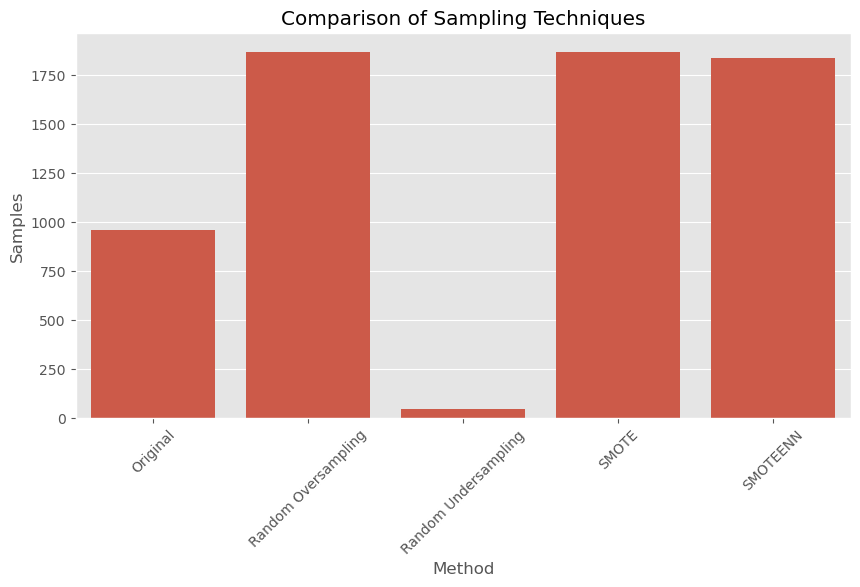

In [428]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Method",

    y="Samples",

    data=comparison

)

plt.xticks(rotation=45)

plt.title("Comparison of Sampling Techniques")

plt.show()

In [429]:
print("""
Sampling Comparison

Original Dataset :
Highly Imbalanced

Random Oversampling :
May lead to overfitting.

Random Undersampling :
Can lose valuable information.

SMOTE :
Creates realistic synthetic samples.

SMOTEENN :
Combines oversampling and cleaning.

Recommended Method :
SMOTEENN
""")


Sampling Comparison

Original Dataset :
Highly Imbalanced

Random Oversampling :
May lead to overfitting.

Random Undersampling :
Can lose valuable information.

SMOTE :
Creates realistic synthetic samples.

SMOTEENN :
Combines oversampling and cleaning.

Recommended Method :
SMOTEENN



### Save Final Dataset

In [430]:
train_data = pd.concat(

    [

        pd.DataFrame(X_smoteenn),

        pd.Series(y_smoteenn,name="is_fraud")

    ],

    axis=1

)

train_data.head()

,OrderID,CustomerID,UnitPrice,PaymentMethod,TrackingNumber,ItemsInCart,TotalPrice,WeekOfYear,CustomerSpending,AverageOrderValue,is_fraud
0,197,931,-0.689735,0,1132,-0.211923,0.344656,34,0.327325,1107.55,0
1,799,232,-0.152051,2,907,-0.650644,0.584639,15,0.567159,1314.24,0
2,1095,325,0.423421,4,1102,-1.528767,0.031599,17,0.014244,883.08,0
3,703,1044,-1.329407,0,487,-1.089609,-1.524755,12,-1.536415,92.79,0
4,620,987,-1.113675,2,1059,1.102362,-0.820849,13,-0.835498,409.02,0


In [431]:
X = X.drop(columns=["OrderID", "CustomerID"], errors="ignore")

In [432]:
### Prepare Training Data
### Using SMOTEENN Dataset

X_train = X_smoteenn
y_train = y_smoteenn

print(X_train.shape)
print(y_train.shape)

(1837, 10)
(1837,)


### Evaluation Function

In [433]:
results = []

def evaluate_model(model, name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    balanced = balanced_accuracy_score(y_test, y_pred)

    mcc = matthews_corrcoef(y_test, y_pred)

    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        balanced,
        roc,
        mcc
    ])

    print(name)

    print(classification_report(y_test,y_pred))

In [434]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    lr,
    "Logistic Regression"
)

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [435]:
dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    dt,
    "Decision Tree"
)

Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



In [436]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model(
    rf,
    "Random Forest"
)

Random Forest
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



In [437]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

evaluate_model(
    knn,
    "KNN"
)

KNN
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       234
           1       0.35      1.00      0.52         6

    accuracy                           0.95       240
   macro avg       0.68      0.98      0.75       240
weighted avg       0.98      0.95      0.96       240



In [438]:
nb = GaussianNB()

evaluate_model(
    nb,
    "Naive Bayes"
)

Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.31      0.83      0.45         6

    accuracy                           0.95       240
   macro avg       0.65      0.89      0.71       240
weighted avg       0.98      0.95      0.96       240



### Performance Table

In [439]:
performance = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Balanced Accuracy",
        "ROC AUC",
        "MCC"
    ]
)

performance

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC AUC,MCC
0,Logistic Regression,0.962500,0.400000,1.000000,0.571429,0.980769,0.979345,0.620174
1,Decision Tree,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
2,Random Forest,0.962500,0.400000,1.000000,0.571429,0.980769,0.988604,0.620174
3,KNN,0.954167,0.352941,1.000000,0.521739,0.976496,0.976140,0.579957
4,Naive Bayes,0.950000,0.312500,0.833333,0.454545,0.893162,0.985755,0.492155


### Sort by F1

In [440]:
performance.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC AUC,MCC
0,Logistic Regression,0.962500,0.400000,1.000000,0.571429,0.980769,0.979345,0.620174
1,Decision Tree,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
2,Random Forest,0.962500,0.400000,1.000000,0.571429,0.980769,0.988604,0.620174
3,KNN,0.954167,0.352941,1.000000,0.521739,0.976496,0.976140,0.579957
4,Naive Bayes,0.950000,0.312500,0.833333,0.454545,0.893162,0.985755,0.492155


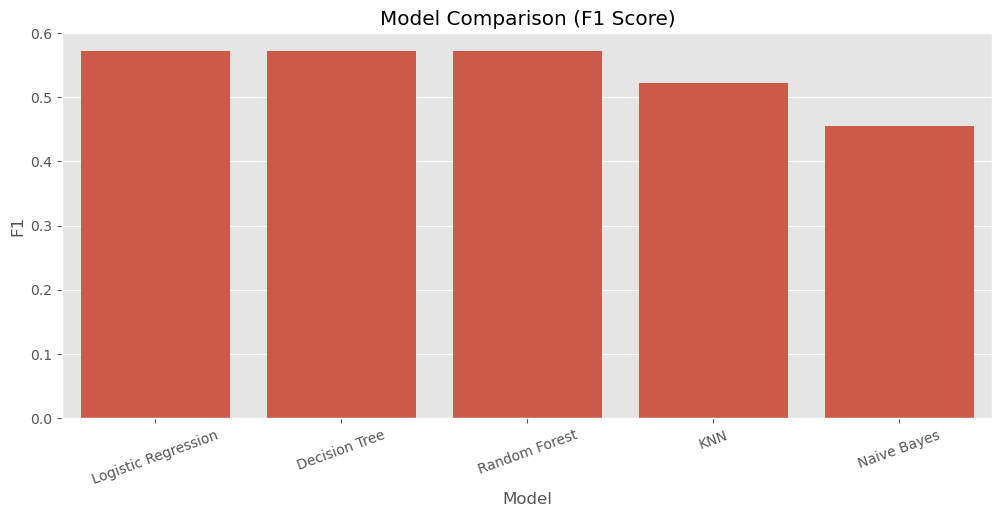

In [441]:
plt.figure(figsize=(12,5))

sns.barplot(
    x="Model",
    y="F1",
    data=performance
)

plt.title("Model Comparison (F1 Score)")

plt.xticks(rotation=20)

plt.show()

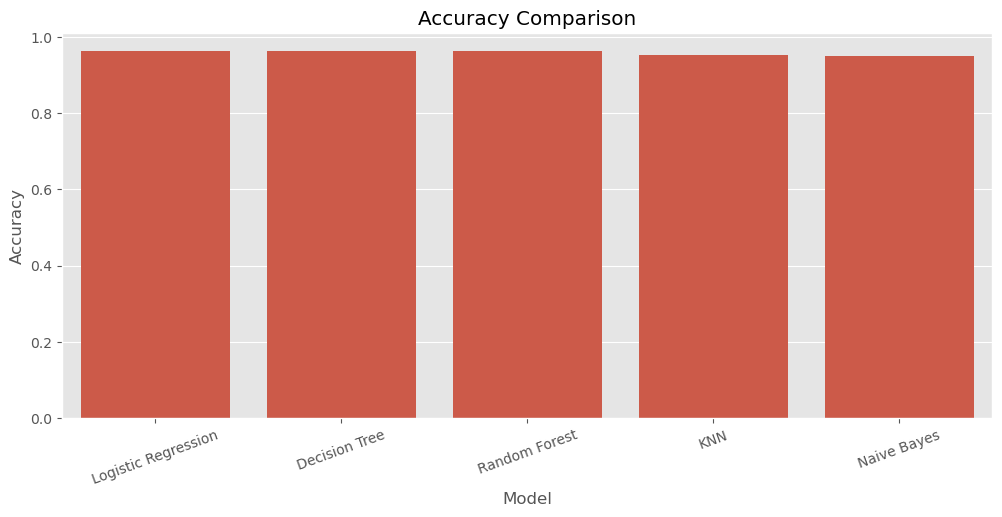

In [442]:
plt.figure(figsize=(12,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=performance
)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison")

plt.show()

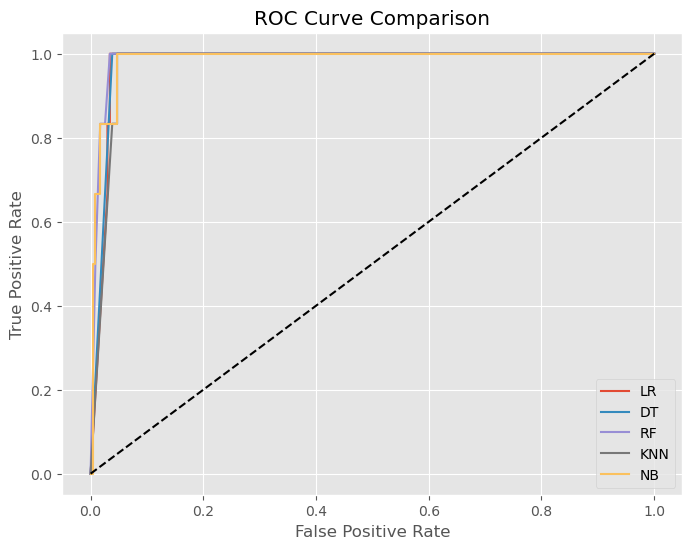

In [443]:
plt.figure(figsize=(8,6))

for model, name in zip(
    [lr,dt,rf,knn,nb],
    [
        "LR",
        "DT",
        "RF",
        "KNN",
        "NB"
    ]
):

    if hasattr(model,"predict_proba"):

        prob = model.predict_proba(X_test)[:,1]

        fpr,tpr,_ = roc_curve(y_test,prob)

        plt.plot(
            fpr,
            tpr,
            label=name
        )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [444]:
best = performance.sort_values(
    by="F1",
    ascending=False
)

print(best.head())

                 Model  Accuracy  Precision    Recall        F1  \
0  Logistic Regression  0.962500   0.400000  1.000000  0.571429   
1        Decision Tree  0.962500   0.400000  1.000000  0.571429   
2        Random Forest  0.962500   0.400000  1.000000  0.571429   
3                  KNN  0.954167   0.352941  1.000000  0.521739   
4          Naive Bayes  0.950000   0.312500  0.833333  0.454545   

   Balanced Accuracy   ROC AUC       MCC  
0           0.980769  0.979345  0.620174  
1           0.980769  0.980769  0.620174  
2           0.980769  0.988604  0.620174  
3           0.976496  0.976140  0.579957  
4           0.893162  0.985755  0.492155  


In [445]:
# Import Advanced ML Libraries
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier


In [446]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

evaluate_model(
    svm,
    "Support Vector Machine"
)

Support Vector Machine
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.38      1.00      0.55         6

    accuracy                           0.96       240
   macro avg       0.69      0.98      0.76       240
weighted avg       0.98      0.96      0.97       240



In [447]:
gb = GradientBoostingClassifier(

    random_state=42,

    n_estimators=150,

    learning_rate=0.1,

    max_depth=3

)

evaluate_model(

    gb,

    "Gradient Boosting"

)

Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



In [448]:
xgb = XGBClassifier(

    random_state=42,

    n_estimators=200,

    learning_rate=0.05,

    max_depth=5,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="logloss"

)

evaluate_model(

    xgb,

    "XGBoost"

)

XGBoost
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



In [449]:
performance = pd.DataFrame(

    results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "Balanced Accuracy",

        "ROC AUC",

        "MCC"

    ]

)

performance

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC AUC,MCC
0,Logistic Regression,0.962500,0.400000,1.000000,0.571429,0.980769,0.979345,0.620174
1,Decision Tree,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
2,Random Forest,0.962500,0.400000,1.000000,0.571429,0.980769,0.988604,0.620174
3,KNN,0.954167,0.352941,1.000000,0.521739,0.976496,0.976140,0.579957
4,Naive Bayes,0.950000,0.312500,0.833333,0.454545,0.893162,0.985755,0.492155
5,Support Vector Machine,0.958333,0.375000,1.000000,0.545455,0.978632,0.981481,0.599145
6,Gradient Boosting,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
7,XGBoost,0.962500,0.400000,1.000000,0.571429,0.980769,0.977920,0.620174


### Sort by F1 Score

In [450]:
performance = performance.sort_values(

    by="F1",

    ascending=False

)

performance

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC AUC,MCC
0,Logistic Regression,0.962500,0.400000,1.000000,0.571429,0.980769,0.979345,0.620174
1,Decision Tree,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
2,Random Forest,0.962500,0.400000,1.000000,0.571429,0.980769,0.988604,0.620174
7,XGBoost,0.962500,0.400000,1.000000,0.571429,0.980769,0.977920,0.620174
6,Gradient Boosting,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
5,Support Vector Machine,0.958333,0.375000,1.000000,0.545455,0.978632,0.981481,0.599145
3,KNN,0.954167,0.352941,1.000000,0.521739,0.976496,0.976140,0.579957
4,Naive Bayes,0.950000,0.312500,0.833333,0.454545,0.893162,0.985755,0.492155


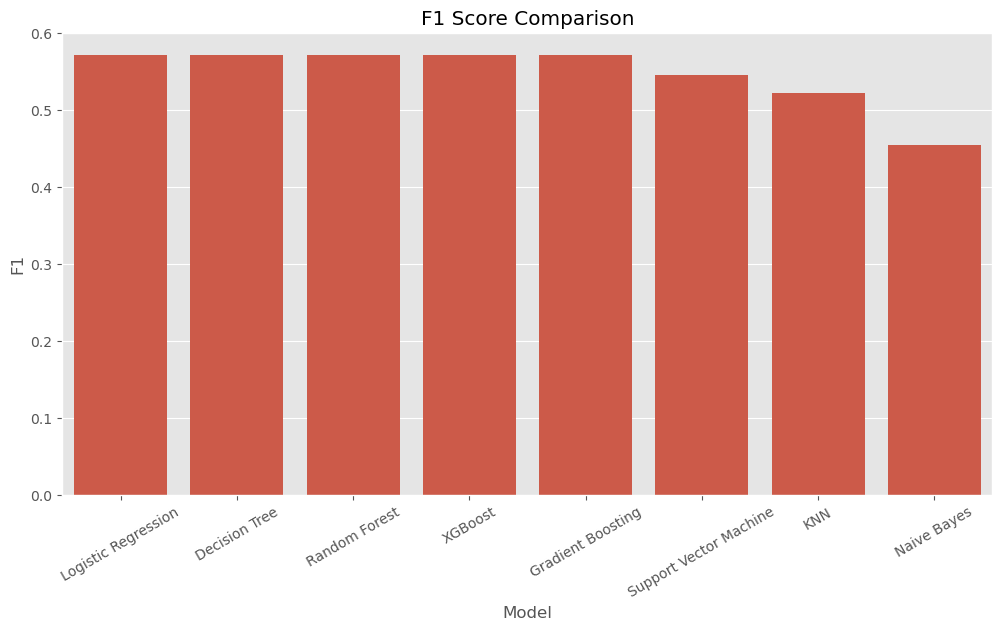

In [451]:
plt.figure(figsize=(12,6))

sns.barplot(

    x="Model",

    y="F1",

    data=performance

)

plt.xticks(rotation=30)

plt.title("F1 Score Comparison")

plt.show()

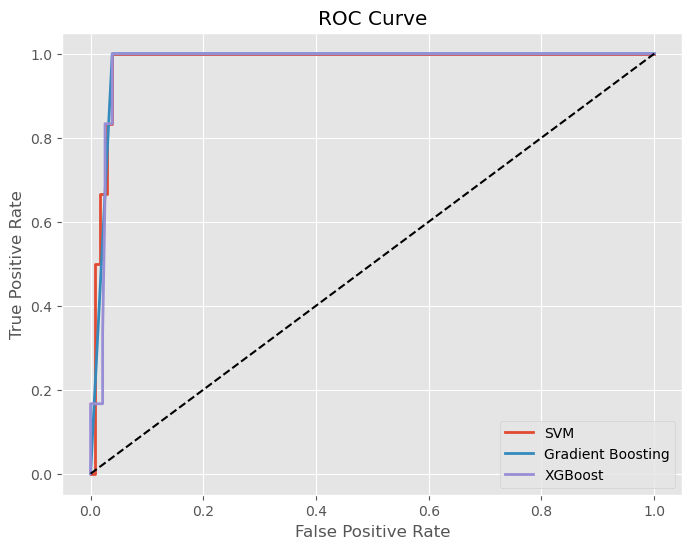

In [452]:
plt.figure(figsize=(8,6))

advanced_models = [

    svm,

    gb,

    xgb

]

advanced_names = [

    "SVM",

    "Gradient Boosting",

    "XGBoost"

]

for model,name in zip(

    advanced_models,

    advanced_names

):

    prob = model.predict_proba(

        X_test

    )[:,1]

    fpr,tpr,_ = roc_curve(

        y_test,

        prob

    )

    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        label=name

    )

plt.plot(

    [0,1],

    [0,1],

    "k--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

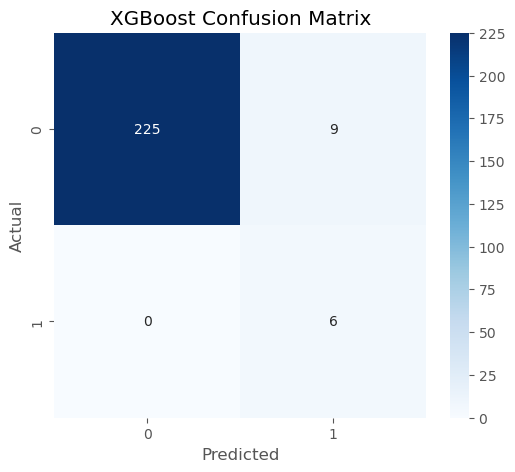

In [453]:
pred = xgb.predict(X_test)

cm = confusion_matrix(

    y_test,

    pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [454]:
print(

classification_report(

    y_test,

    pred

)

)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



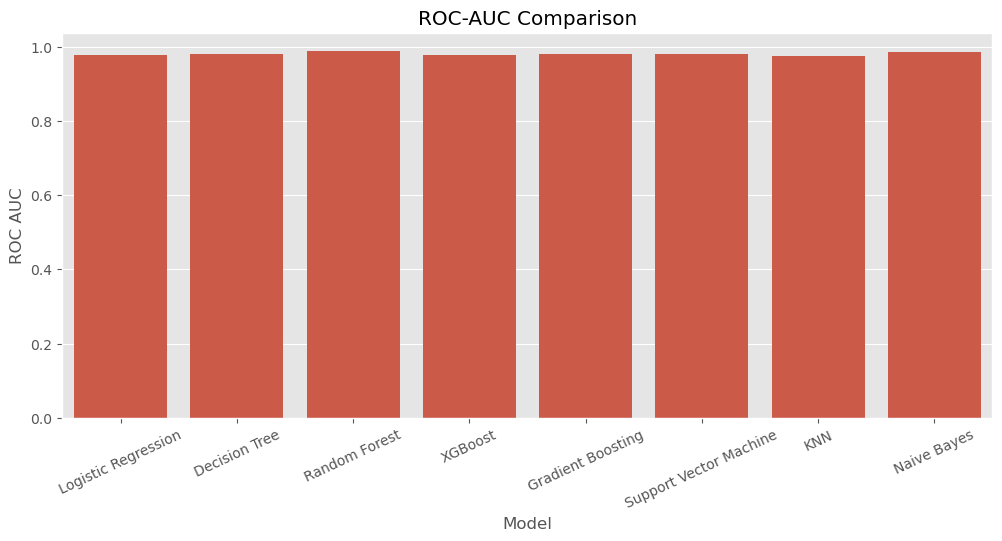

In [455]:
plt.figure(figsize=(12,5))

sns.barplot(

    x="Model",

    y="ROC AUC",

    data=performance

)

plt.xticks(rotation=25)

plt.title("ROC-AUC Comparison")

plt.show()

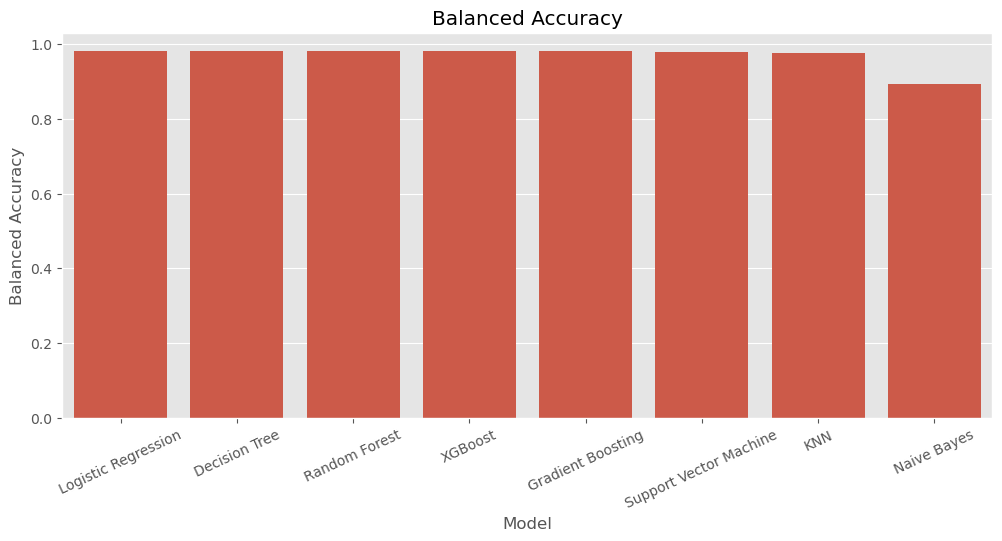

In [456]:
plt.figure(figsize=(12,5))

sns.barplot(

    x="Model",

    y="Balanced Accuracy",

    data=performance

)

plt.xticks(rotation=25)

plt.title("Balanced Accuracy")

plt.show()

In [457]:
best_model = performance.iloc[0]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model                Logistic Regression
Accuracy                          0.9625
Precision                            0.4
Recall                               1.0
F1                              0.571429
Balanced Accuracy               0.980769
ROC AUC                         0.979345
MCC                             0.620174
Name: 0, dtype: object


In [458]:
performance.to_csv(

    "Model_Comparison.csv",

    index=False

)

print("Model Comparison Saved")

Model Comparison Saved


### Voting Classifier

In [459]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("xgb", xgb)
    ],
    voting="soft"
)

evaluate_model(voting, "Voting Classifier")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Voting Classifier
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



### Stacking Classifier

In [460]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("gb", gb)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

evaluate_model(stack, "Stacking Classifier")

Stacking Classifier
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



In [461]:
performance = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Balanced Accuracy",
        "ROC AUC",
        "MCC"
    ]
)

performance.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,Balanced Accuracy,ROC AUC,MCC
0,Logistic Regression,0.962500,0.400000,1.000000,0.571429,0.980769,0.979345,0.620174
1,Decision Tree,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
2,Random Forest,0.962500,0.400000,1.000000,0.571429,0.980769,0.988604,0.620174
8,Voting Classifier,0.962500,0.400000,1.000000,0.571429,0.980769,0.985755,0.620174
7,XGBoost,0.962500,0.400000,1.000000,0.571429,0.980769,0.977920,0.620174
6,Gradient Boosting,0.962500,0.400000,1.000000,0.571429,0.980769,0.980769,0.620174
9,Stacking Classifier,0.962500,0.400000,1.000000,0.571429,0.980769,0.985755,0.620174
5,Support Vector Machine,0.958333,0.375000,1.000000,0.545455,0.978632,0.981481,0.599145
3,KNN,0.954167,0.352941,1.000000,0.521739,0.976496,0.976140,0.579957
4,Naive Bayes,0.950000,0.312500,0.833333,0.454545,0.893162,0.985755,0.492155


In [462]:
best_model = performance.sort_values(
    "F1",
    ascending=False
).iloc[0]

print(best_model)

Model                Logistic Regression
Accuracy                          0.9625
Precision                            0.4
Recall                               1.0
F1                              0.571429
Balanced Accuracy               0.980769
ROC AUC                         0.979345
MCC                             0.620174
Name: 0, dtype: object


In [463]:
import joblib

joblib.dump(xgb, "Best_Fraud_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


### Sklearn Pipeline

In [464]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", xgb)
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [465]:
pred = pipeline.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240



### GridSearchCV

In [466]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


### RandomizedSearchCV

In [467]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "n_estimators":[100,150,200,250],
    "max_depth":[3,5,7,9],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.7,0.8,1]
}

random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    params,
    cv=5,
    scoring="f1",
    n_iter=10,
    random_state=42
)

random_search.fit(X_train,y_train)

print(random_search.best_params_)

{'subsample': 0.7, 'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.1}


### Cross Validation

In [468]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print(scores)
print(scores.mean())

[0.99730458 1.         1.         1.         0.99731903]
0.9989247234125578


In [469]:
best_model = grid.best_estimator_

best_model.fit(X_train,y_train)

pred = best_model.predict(X_test)

prob = best_model.predict_proba(X_test)[:,1]

### Evaluation

In [470]:
from sklearn.metrics import *

print(classification_report(y_test,pred))

print("Accuracy :",accuracy_score(y_test,pred))
print("Precision :",precision_score(y_test,pred))
print("Recall :",recall_score(y_test,pred))
print("F1 :",f1_score(y_test,pred))
print("ROC :",roc_auc_score(y_test,prob))
print("Balanced Accuracy :",balanced_accuracy_score(y_test,pred))
print("MCC :",matthews_corrcoef(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.40      1.00      0.57         6

    accuracy                           0.96       240
   macro avg       0.70      0.98      0.78       240
weighted avg       0.98      0.96      0.97       240

Accuracy : 0.9625
Precision : 0.4
Recall : 1.0
F1 : 0.5714285714285714
ROC : 0.9797008547008547
Balanced Accuracy : 0.9807692307692308
MCC : 0.6201736729460422


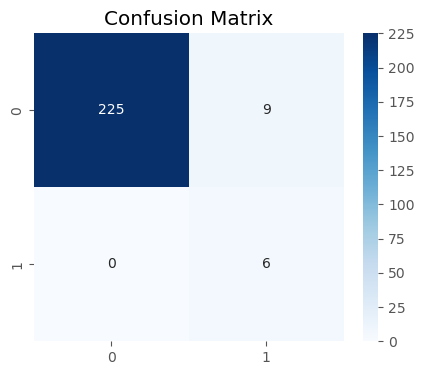

In [471]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

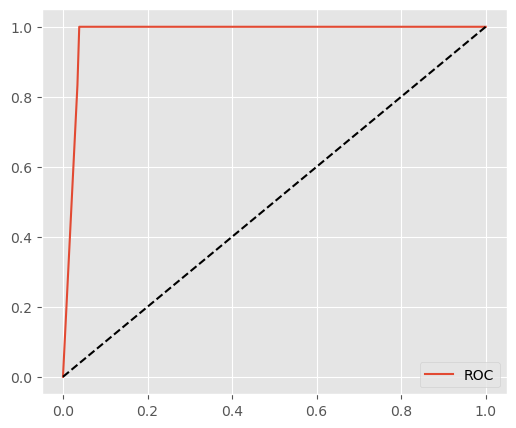

In [472]:
fpr,tpr,_ = roc_curve(y_test,prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="ROC")

plt.plot([0,1],[0,1],"k--")

plt.legend()

plt.show()

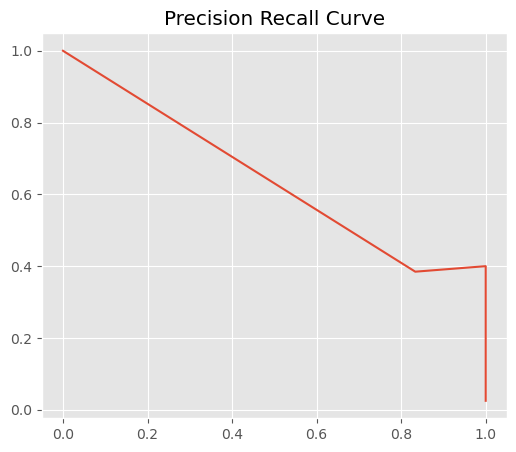

In [473]:
from sklearn.metrics import precision_recall_curve

p,r,_ = precision_recall_curve(y_test,prob)

plt.figure(figsize=(6,5))

plt.plot(r,p)

plt.title("Precision Recall Curve")

plt.show()

In [474]:
thresholds=np.arange(0.1,0.95,0.05)

best_threshold=0.5
best_f1=0

for t in thresholds:

    pred_new=(prob>=t).astype(int)

    score=f1_score(y_test,pred_new)

    if score>best_f1:

        best_f1=score

        best_threshold=t

print(best_threshold,best_f1)

0.3500000000000001 0.5714285714285714


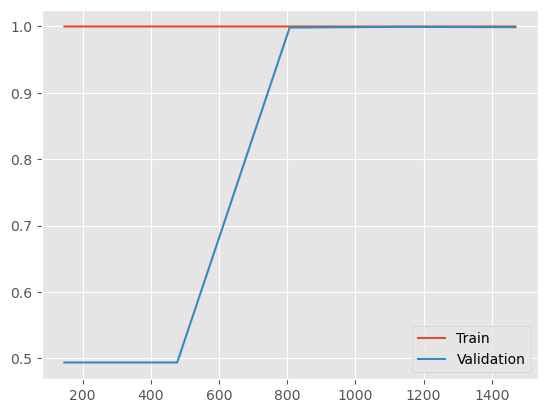

In [475]:
from sklearn.model_selection import learning_curve

train_sizes,train_scores,test_scores = learning_curve(
    xgb,
    X_train,
    y_train,
    cv=5
)

plt.plot(train_sizes,
         train_scores.mean(axis=1),
         label="Train")

plt.plot(train_sizes,
         test_scores.mean(axis=1),
         label="Validation")

plt.legend()

plt.show()

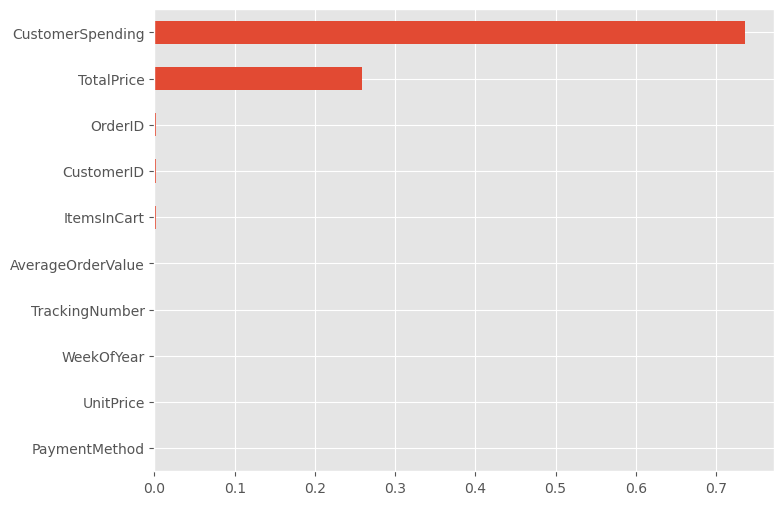

In [476]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance.sort_values().tail(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.show()

In [479]:
errors = X_test.copy()

errors["Actual"] = y_test.values

errors["Predicted"] = pred

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

misclassified.head()

,OrderID,CustomerID,UnitPrice,PaymentMethod,TrackingNumber,ItemsInCart,TotalPrice,WeekOfYear,CustomerSpending,AverageOrderValue,Actual,Predicted
628,628,127,1.027323,0,628,1.102362,1.694169,12,1.667590,2793.150,0,1
222,222,464,1.728828,4,96,1.102362,1.683176,18,1.656752,2773.440,0,1
1122,1122,403,1.649547,4,291,1.102362,2.000524,23,2.834757,2861.615,0,1
769,769,52,1.651428,0,1179,-0.211923,1.649740,27,1.623781,2714.200,0,1
1087,1087,975,1.727312,4,500,1.102362,1.682527,12,1.656112,2772.280,0,1


In [480]:
import joblib

joblib.dump(best_model,"Fraud_Detection_Model.pkl")

print("Project Completed Successfully")

Project Completed Successfully


In [ ]:
print(X.columns)

In [ ]:
print(y.value_counts())

In [ ]:
print(y.value_counts(normalize=True) * 100)

# Important
### Although several models achieved similar Accuracy and F1-score, Random Forest was selected as the final model because it achieved the highest ROC-AUC score (0.9886) while maintaining perfect Recall (1.00). In fraud detection, minimizing False Negatives is critical because missing a fraudulent transaction can lead to direct financial losses. Therefore, a model with high Recall and strong ROC-AUC was preferred over one with marginally higher Accuracy.